In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/real-world-fashion-mnist/pullover_3.png
/kaggle/input/real-world-fashion-mnist/sneaker_3.png
/kaggle/input/real-world-fashion-mnist/ankleboot_1.png
/kaggle/input/real-world-fashion-mnist/shirt_3.png
/kaggle/input/real-world-fashion-mnist/sandal_3.png
/kaggle/input/real-world-fashion-mnist/dress_1.png
/kaggle/input/real-world-fashion-mnist/trouser_1.png
/kaggle/input/real-world-fashion-mnist/bag_3.png
/kaggle/input/real-world-fashion-mnist/sneaker_1.png
/kaggle/input/real-world-fashion-mnist/shirt_1.png
/kaggle/input/real-world-fashion-mnist/coat_2.png
/kaggle/input/real-world-fashion-mnist/sandal_2.png
/kaggle/input/real-world-fashion-mnist/sneaker_2.png
/kaggle/input/real-world-fashion-mnist/tshirt_3.png
/kaggle/input/real-world-fashion-mnist/shirt_2.png
/kaggle/input/real-world-fashion-mnist/bag_1.png
/kaggle/input/real-world-fashion-mnist/sandal_1.png
/kaggle/input/real-world-fashion-mnist/ankleboot_2.png
/kaggle/input/real-world-fashion-mnist/coat_1.png
/kaggle/input/

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import tree
from sklearn import ensemble
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set_style('whitegrid')

# Fashion MNIST

- Fashion MNIST is a dataset of Zalando cloth images. There are 60000 datatpoints in the training set, and 10000 in the test set.
- Each image is 28 pixels in height and 28 pixels in width, for a total of 784 pixels, which are our predictors. 
- Each pixel has a single pixel-value associated with it, indicating the lightness or darkness of that pixel, with higher numbers meaning darker. This pixel-value is an integer between 0 and 255. 
- The first column consists of the class labels, and represents the article of clothing. There are 10 classes: <br>
0 T-shirt/top <br>
1 Trouser <br>
2 Pullover <br>
3 Dress <br>
4 Coat <br>
5 Sandal <br>
6 Shirt <br>
7 Sneaker <br>
8 Bag <br>
9 Ankle boot <br>

In [46]:
#let's load the dataset
df = pd.read_csv('../input/fashionmnist/fashion-mnist_train.csv')
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Exploratory Analysis

Since we will add some columns, better to make a copy of the dataset when exploring the data.

In [47]:
df_expl = df.copy()

Let's start with some basic functions to explore the data: info() and describe()

In [48]:
df_expl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [49]:
df_expl.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


In our case, these functions are not very insightful.

We want to add one column with categories names instead of labels, this will be helpful later on.

In [51]:
category_df = pd.DataFrame([
    [0, "T-shirt/top"],
    [1, "Trouser"],
    [2, "Pullover"],
    [3, "Dress"],
    [4, "Coat"],
    [5, "Sandal"],
    [6, "Shirt"],
    [7, "Sneaker"],
    [8, "Bag"],
    [9, "Ankle boot"],
], columns=["id", "category"])
category_df

,id,category
0,0,T-shirt/top
1,1,Trouser
2,2,Pullover
3,3,Dress
4,4,Coat
5,5,Sandal
6,6,Shirt
7,7,Sneaker
8,8,Bag
9,9,Ankle boot


In [52]:
df_expl = df_expl.merge(right=category_df,how="inner",left_on="label",right_on="id").drop(axis=1,columns="id")
df_expl

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,category
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pullover
1,2,0,0,0,0,1,1,0,0,0,...,0,118,190,162,82,0,0,0,0,Pullover
2,2,0,0,0,0,0,0,0,0,16,...,0,1,1,1,1,0,0,0,0,Pullover
3,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pullover
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Pullover
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Trouser
59996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Trouser
59997,1,0,0,0,0,0,0,0,0,24,...,25,0,0,0,0,0,0,0,0,Trouser
59998,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Trouser


### Image visualization

To have a better understanding of data, we want to plot some images. In the following cell, we used the function randint to generate random numbers.
We want to have 5 random picture for each category,so we have first a for cycle to loop through categories and then a for cycle to generate 5 images each time.

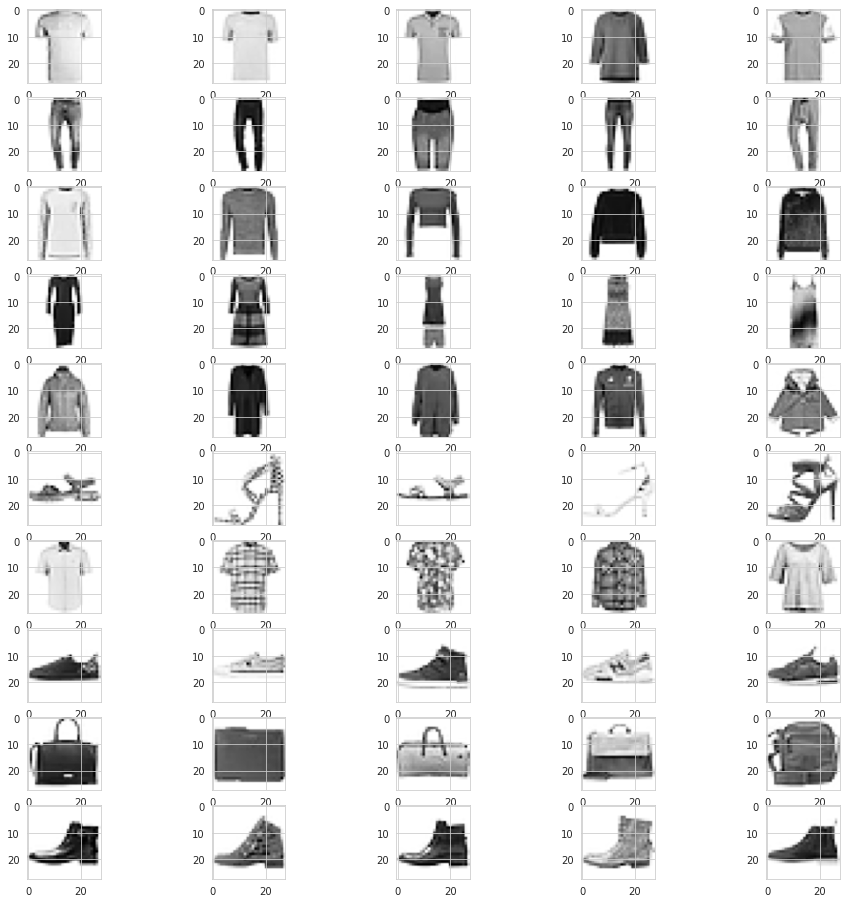

In [53]:
from random import seed
from random import randint

fig=plt.figure(figsize=(16, 16))
columns = 5
rows = 10

seed(1)
p=0
for x in range(1,rows+1):
    for i in range(1,columns+1):
        value = randint(0, 6000)
        fig.add_subplot(rows, columns, (x-1)*5+i)
        plt.imshow(df[df['label']==(x-1)].to_numpy()[value,1:].reshape((28,28)), cmap="Greys")

plt.show()

Why are pictures so blurried? The obvious reason is that 28x28 pixels is not a good resolution, these pictures are very very small. Let's plot them in their original size

In [54]:
def display_image_in_actual_size(im):
    dpi = 80
    im_data = im
    (height, width), depth = im_data.shape, 1

    # What size does the figure need to be in inches to fit the image?
    figsize = width / float(dpi), height / float(dpi)

    # Create a figure of the right size with one axis that takes up the full figure
    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0, 0, 1, 1])

    # Hide spines, ticks, etc.
    ax.axis('off')

    # Display the image.
    ax.imshow(im_data, cmap='Greys')

    plt.show()

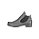

In [55]:
display_image_in_actual_size(df.to_numpy()[1,1:].reshape((28,28)))

Now the picture is way more defined, but very small indeed.

## Labels distribution

Is the data homogeneous? How many datapoints for each category do we have?

In [56]:
df_count = df_expl.groupby(['label','category'])['pixel1'].count()
df_count

label  category   
0      T-shirt/top    6000
1      Trouser        6000
2      Pullover       6000
3      Dress          6000
4      Coat           6000
5      Sandal         6000
6      Shirt          6000
7      Sneaker        6000
8      Bag            6000
9      Ankle boot     6000
Name: pixel1, dtype: int64

We have 6000 datapoints per label, this means the dataset is homogenously distributed. This is great, having more data for one label would have created some troubles. Now we want to visualize this through a pie chart.

([<matplotlib.patches.Wedge at 0x7f54c8ec1490>,
 [Text(1.0461621663333946, 0.3399186987098808, 'T-shirt/top'),
  Text(0.6465637650236903, 0.8899187028927925, 'Trousers'),
  Text(-2.5747358111484753e-08, 1.0999999999999999, 'Pullover'),
  Text(-0.6465638066837905, 0.8899186726249574, 'Dress'),
  Text(-1.0461621822461362, 0.3399186497354952, 'Coat'),
  Text(-1.0461621504206509, -0.33991874768426583, 'Sandal'),
  Text(-0.6465637233635886, -0.8899187331606258, 'Shirt'),
  Text(7.724207457870327e-08, -1.0999999999999974, 'Sneaker'),
  Text(0.6465638483438898, -0.88991864235712, 'Bag'),
  Text(1.0461621981588753, -0.33991860076110864, 'Ankle_boot')])

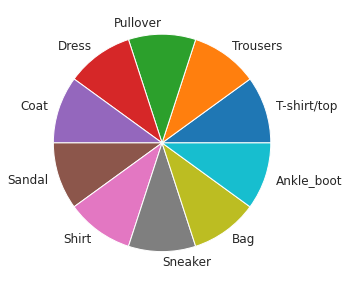

In [57]:
values = df_count.values
labels = ['T-shirt/top','Trousers','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle_boot']
fig, ax = plt.subplots(figsize=(6,5))
ax.pie(values, labels=labels,textprops={'fontsize': 12})
#fig.savefig('piechart', transparent=True)

## Labels pixels intensity
Are there any significant differences between cloth categories, in terms of average intensity of colour and average total number of pixels per image?

When a pixel has value of 0, it means that it is "empty". Since we want to get the average of pixels' intensity and the total number of pixels for each image in the dataset, we replace these zeros with NaN, which are not counted in the calculations for definition. We also need to temporarly drop label column because it is numerical and shouldn't be included in the calculations.

In [58]:
# Averaging pixel intensity for each row
df_expl['avg_intensity'] = df_expl.replace(0, np.NaN).drop('label', axis=1).mean(axis=1)
# Now counting number of "active" pixels (intensity value strictly greater than 0)
df_expl['tot_pixel'] = df_expl.replace(0, np.NaN).drop('label', axis=1).count(axis=1)
df_expl

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,category,avg_intensity,tot_pixel
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Pullover,189.188285,480
1,2,0,0,0,0,1,1,0,0,0,...,190,162,82,0,0,0,0,Pullover,115.932271,504
2,2,0,0,0,0,0,0,0,0,16,...,1,1,1,0,0,0,0,Pullover,72.389286,562
3,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Pullover,216.591716,340
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Pullover,193.308008,489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Trouser,178.917293,268
59996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Trouser,200.895131,269
59997,1,0,0,0,0,0,0,0,0,24,...,0,0,0,0,0,0,0,Trouser,171.765957,331
59998,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,Trouser,157.676923,262


Now, we can group by the category and see average values for these two variables

In [59]:
df_lgr = df_expl.groupby(['label','category']).agg({'avg_intensity':'mean','tot_pixel':'mean'}).reset_index()
df_lgr

,label,category,avg_intensity,tot_pixel
0,0,T-shirt/top,139.543680,468.394833
1,1,Trouser,163.605188,275.831500
2,2,Pullover,147.749475,510.458833
3,3,Dress,155.038628,338.606500
4,4,Coat,163.042872,473.956833
5,5,Sandal,107.280145,253.675000
6,6,Shirt,135.208955,495.336833
7,7,Sneaker,126.411480,266.617167
8,8,Bag,152.707477,460.381000
9,9,Ankle boot,158.265760,382.638333


Observations:

* trousers, sandal, and sneaker have the less tot_pixel, i.e. the image is more "empty". Indeed, if we think about trousers, there is usually a big space between the legs, and if we think about shoes, they are two with also spaces in between. So, these three types have less concentrated images
* trousers, coat, and boots have higher average intensity. This could be due to the usual colours of these clothes, which are higher often (dark colors are more popular than light ones).

However, there are no strong pattern, conclutions are hard to be inferred

Let's plot them using a barplot

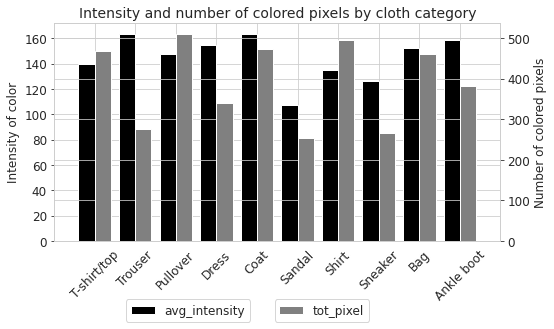

<Figure size 432x288 with 0 Axes>

In [60]:
fig, ax = plt.subplots(figsize=(8,4)) 
ax2 = ax.twinx() #we want to plot 2 variables on 2 axes, so we use twinx to generate a second y axis

width = 0.4

rects1 = df_lgr.avg_intensity.plot(kind='bar', color='black', ax=ax, width=width, position=1)
rects2 = df_lgr.tot_pixel.plot(kind='bar', color='grey', ax=ax2, width=width, position=0)

ax.set_ylabel('Intensity of color', fontsize=12)
ax2.set_ylabel('Number of colored pixels', fontsize=12)
ax.set_title('Intensity and number of colored pixels by cloth category', fontsize=14)
ax.tick_params(axis="y", labelsize=12)
ax2.tick_params(axis="y", labelsize=12)

labels = df_lgr['category']
x = np.arange(len(labels))  

ax.legend(fontsize=12, loc='lower center', bbox_to_anchor=(0.3, -0.4))
ax2.legend(fontsize=12, loc='lower center', bbox_to_anchor=(0.6, -0.4))

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, rotation=45)

plt.xlim(-1,10) #this because saving the fig was cutting some parts

plt.show()

plt.subplots_adjust(right=4)

#fig.savefig("hist", transparent=True, bbox_inches='tight')

## Pixel activation map

Which are the most common pixels (i.e. the ones that most images have), and which ones are the less frequent?

To this we count how many times each pixel appears and we take the first 20 and last 20.

In [61]:
descend = df_expl.replace(0, np.NaN).drop(['label','category','tot_pixel','avg_intensity'], axis=1).count().sort_values(ascending = False)
most_common = descend.head(20)
most_common

pixel494    58330
pixel493    58271
pixel466    58222
pixel465    57900
pixel521    57666
pixel488    57659
pixel438    57555
pixel522    57504
pixel467    57500
pixel489    57366
pixel516    57319
pixel437    57194
pixel460    57189
pixel410    57179
pixel487    57122
pixel492    57035
pixel439    57029
pixel354    57019
pixel517    57019
pixel495    57015
dtype: int64

In [62]:
less_common = descend.tail(20)
less_common

pixel141    740
pixel31     733
pixel26     719
pixel729    664
pixel86     656
pixel84     636
pixel758    552
pixel113    473
pixel85     347
pixel58     327
pixel27     294
pixel56     254
pixel784    236
pixel757    208
pixel30     200
pixel57     168
pixel2      128
pixel28      83
pixel29      62
pixel1       14
dtype: int64

This seems pretty obvious: 
* the most common pixels are the ones in the "middle" of an image (remember we have 784 pixels, so pixels 400  / 500 are almost in the middle)
* the less common are the ones in the corners (pixel 1, 2, 28, 758...)

Let's plot the most common ones. How to? We need to:
1. Save these pixels somewhere
2. Create an empty series
3. Put the most common pixels in the empty series
4. Reshape in 28x28 to have an array
5. Plot them with a heatmap (seaborn)


In [63]:
#here I save the most common pixels
numb = [494,493,466,465,521,488,438,522,467,489,516,437,460,410,487,492,439,517,354,495]

In [64]:
zer_arr = np.zeros((784)) #this is a series with 0s only, with length 784 because we have 28x28 pixels
i = 0

for y in numb:
    for i in range(784):
        if i == y:
            zer_arr[i+1] = 1 #here I replace zeros with 1 for the most common pixels. Note that the first pixel is 1, not 0, so we need i+1

In [65]:
matr = zer_arr.reshape((28,28)) #now the series becomes an array 

Text(33.0, 0.5, 'Pixels')

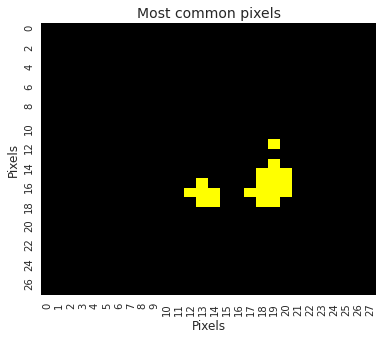

In [66]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(matr, ax=ax, cmap="gnuplot", cbar=False)
ax.set_title("Most common pixels", fontsize=14)
ax.set_xlabel("Pixels", fontsize=12)
ax.set_ylabel("Pixels", fontsize=12)

#fig.savefig("Mostcomm", transparent = True)

Now we want to see the frequency of each pixel, so to have an idea about the distribution. To do this, we count how many times each pixel appear in pictures and then we plot these frequencies through a heatmap. It's same as before but we plot every pixel, not only the most frequent ones.

In [68]:
tot = df_expl.replace(0, np.NaN).drop(['label','category','tot_pixel','avg_intensity'], axis=1).count()
val = tot.values
val = val.reshape((28,28))

Text(33.0, 0.5, 'Pixels')

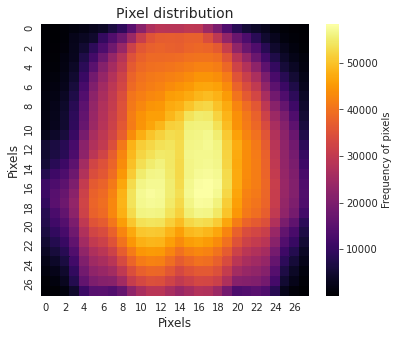

In [69]:
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(val, ax=ax, cbar_kws={'label': 'Frequency of pixels'}, cmap="inferno")
ax.set_title("Pixel distribution", fontsize=14)
ax.set_xlabel("Pixels", fontsize=12)
ax.set_ylabel("Pixels", fontsize=12)
#fig.savefig("pixeldistr", transparent=True)

This is the complete picture: the more yellow, the more frequent they appear, the more black, the least. Of course, pictures are in the middle, while corners are empty. Couple of more observations:
* If you can focus, you can see a shirt in the picture
* You can also see a shoe in the middle
* In the middle of the yellow area, the most frequent pixels, there is an orange line, meaning less frequent pixels than yellow. Probably, this is because of trousers, which have a big hole between legs.

We have seen that some characteristics of images are recognizable in the distribution of pixels. What happens if we do the same for each cloth category?

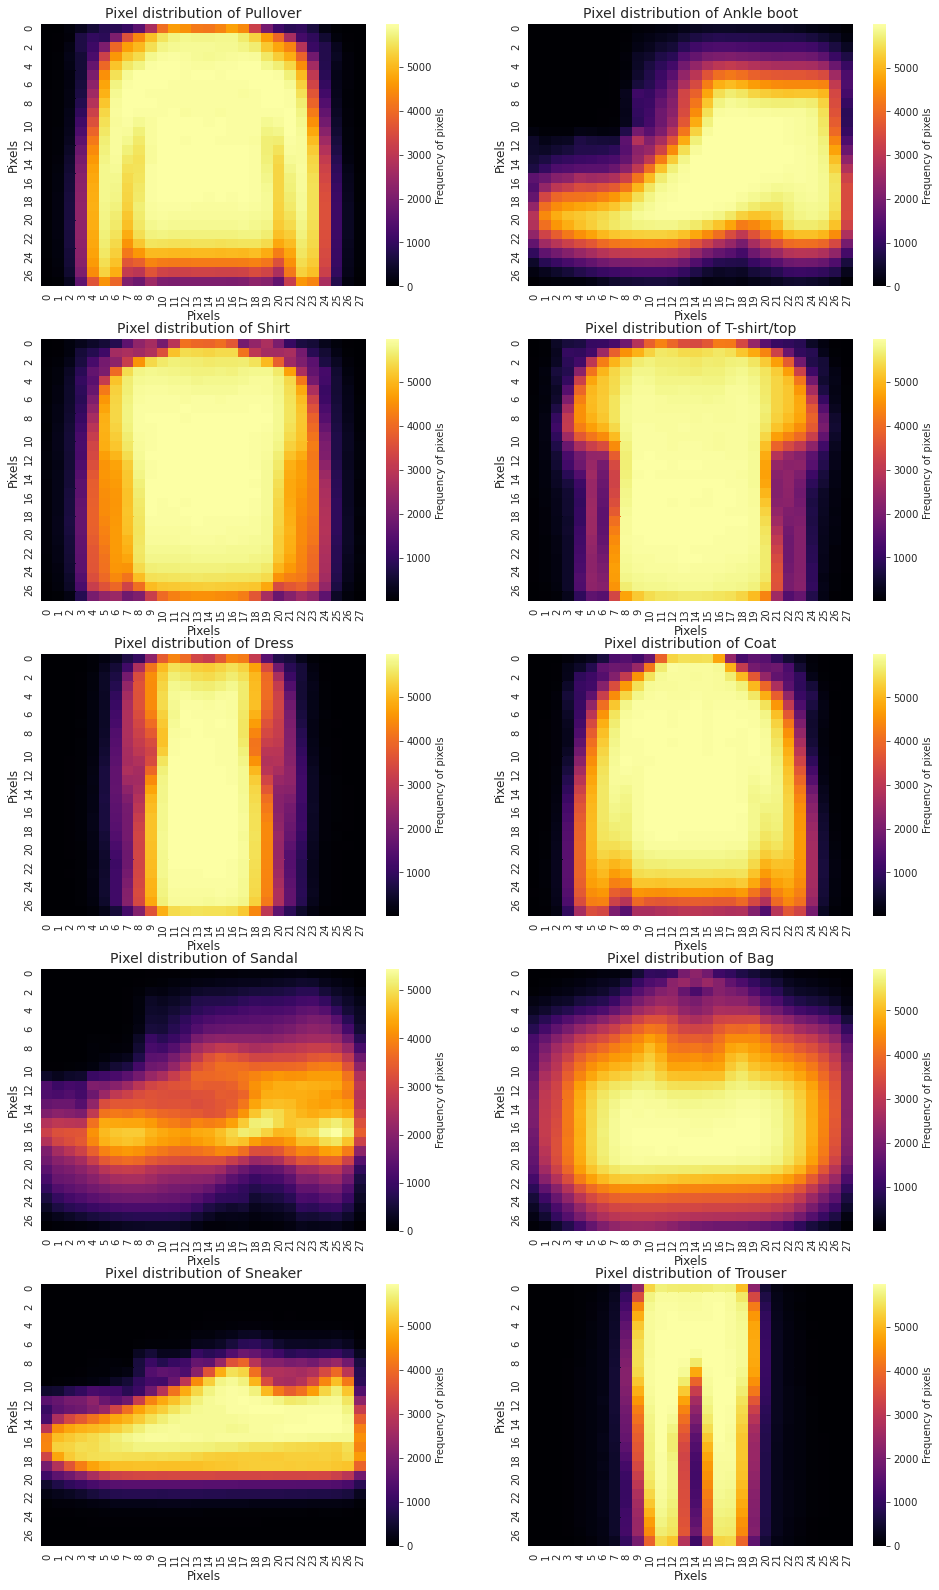

In [77]:
fig=plt.figure(figsize=(16, 28))
columns = 2
rows = 5

i=1
for cat in df_expl['category'].unique():
    tot_cat = df_expl[df_expl['category']==cat].replace(0, np.NaN).drop(['label','category','tot_pixel','avg_intensity'], axis=1).count()
    val_cat = tot_cat.values.reshape((28,28))
    ax = fig.add_subplot(rows, columns, i)
    sns.heatmap(val_cat, ax=ax, cbar_kws={'label': 'Frequency of pixels'}, cmap="inferno")
    ax.set_title("Pixel distribution of "+cat, fontsize=14)
    ax.set_xlabel("Pixels", fontsize=12)
    ax.set_ylabel("Pixels", fontsize=12)
    
    #fig.savefig("Distr" + str(i))
    i += 1
plt.show()

This is very interesting. 
* By plotting the frequencies of pixel by category, we get the "average" image of that category. 
* Some categories are more defined, other not really. This depends on how similar images of the same category are. Sandals are apparently the most heterogeneous.

# Modelization

As opposed to what was done in class, we will not be using classic binary classification. Indeed, we are looking to sort clothes that belong to 10 different classes. Therefore sklearn will automatically resort to methods that generalize the binary classification to multiple classes: namely the one versus one approach (which happens to be more efficient than the one versus all approach).  

Let's start by creating our X and Y. All pixels are predictors, the label of cloth category is our target.

In [78]:
 #we divide by 255 because we want values between 0 and 1. The highest intensity is 255, the lowest (empty pixel) is 0.
X = df.to_numpy()[:,1:]/255
Y = df.to_numpy()[:,0]

In class, we always splitted our dataset into training and test set. In our case, the test dataset was already provided separated from the training one. This is actually good, because we cannot afford to "lose" training data. Indeed, we have many predictors, and to avoid overfitting, we need to ensure many observations as well. 784 predictors and 60000 observations sounds fine. Let's now import our test dataframe.

In [79]:
df_test = pd.read_csv('../input/fashionmnist/fashion-mnist_test.csv')
df_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


Again, we need to create our X and Y, same as before.

In [80]:
X_test = df_test.to_numpy()[:,1:]/255 
Y_test = df_test.to_numpy()[:,0]

## Logistic regression
We want to apply one of the first methods we saw in class, logistic regression. ***Our dataset is huge, training takes very long, roughly 20 min***.

In [89]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=42, max_iter=500, n_jobs=4, verbose=1).fit(X, Y)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 out of   1 | elapsed: 12.2min finished


Sklearn Logistic regression doesn't seem to be parallizable. But there is a way to transform it into something parallelizable so as to faster the training. It's by using neural nets in a certain way. We won't do it in there, as it is far away from the scope of our class.

Let's see how this model worked and how it performs. First of all, we want to look at the intercept of the regression and the coefficients.

In [90]:
print(clf.intercept_)

[ 0.4803768  -2.66575994 -0.63679519  0.56956391 -2.69283173  5.45648377
  0.14604652  2.00148411 -0.90228795 -1.75628031]


We have 10 intercepts, not 1. Why? Because we have 10 possible labels (outcome). About the values of these intercepts there is not much to say.

In [91]:
print(clf.coef_)

[[-7.88942353e-03  3.87928225e-03  4.22954747e-02 ... -5.84832623e-03
   6.26634064e-02  1.15717489e-01]
 [-4.83505935e-05 -6.61883875e-04 -2.13685505e-02 ...  8.39146012e-03
   1.61889409e-02 -2.21953241e-02]
 [-5.85967422e-03 -3.03166493e-04 -7.40608069e-03 ...  2.42120396e-01
   1.50957701e-02  5.60313754e-02]
 ...
 [-1.68780656e-06 -7.97890060e-05 -3.10718325e-04 ... -2.39685837e-02
   3.50935165e-02 -8.02379185e-03]
 [-1.01446469e-02 -3.03450162e-03 -1.59298204e-01 ... -1.42810599e-01
  -3.33589447e-01 -2.22262129e-01]
 [-3.28176231e-06  3.44734087e-03 -3.60598113e-03 ...  7.76256382e-02
   2.21115866e-01  3.49059437e-02]]


In [ ]:
len(clf.coef_[0]) #this returns 784

We have a 2D array with 784 elements (the pixels), each one has 10 values (the labels). If we look at the values, they are incredibly low. Why? Because one single pixel cannot predict the label. It's the combination that is unique for a cloth category.

Now we want to see how good the model performs on our test dataset.

In [94]:
print(clf.score(X_test,Y_test))

0.8542


0.85 is a very high value, the model gives good results. What are the most common mistakes? To do that, we need a confusion matrix.

In [95]:
pd.set_option("display.max_rows", None, "display.max_columns", None) #I want to see the whole matrix although is huge
ones = np.ones(10000) #I need an array of ones to count later
test_predictions = clf.predict(X_test) #array with all the predictions
conf = pd.DataFrame({'actual':Y_test, 'predicted':test_predictions, 'tot':ones}) #I merge the predictions with actual values
conf_matrix = conf.groupby(['actual','predicted'])['tot'].count().reset_index() #I count how many times each case happens
conf_matrix

,actual,predicted,tot
0,0,0,819
1,0,1,3
2,0,2,15
3,0,3,39
4,0,4,1
5,0,5,4
6,0,6,103
7,0,8,16
8,1,0,1
9,1,1,975


Now I want to see the percentages, which is more interesting. Note that the test dataset has 10000 datapoints, 1000 per category, so I can simply divide each value by 1000 to have % in each category.

In [96]:
conf_matrix['perc'] = conf_matrix['tot']/1000
conf_matrix

,actual,predicted,tot,perc
0,0,0,819,0.819
1,0,1,3,0.003
2,0,2,15,0.015
3,0,3,39,0.039
4,0,4,1,0.001
5,0,5,4,0.004
6,0,6,103,0.103
7,0,8,16,0.016
8,1,0,1,0.001
9,1,1,975,0.975


Let's add the cloth category names again, with numbers it is a bit tricky to draw conclusions.

In [97]:
conf_matrix['category_act'] = np.where(conf_matrix['actual']== 0, 'T-shirt/top', np.where(conf_matrix['actual']== 1,'Trousers',np.where(conf_matrix['actual']== 2,'Pullover',np.where(conf_matrix['actual']== 3,'Dress',np.where(conf_matrix['actual']== 4,'Coat',np.where(conf_matrix['actual']== 5,'Sandal',np.where(conf_matrix['actual']== 6,'Shirt',np.where(conf_matrix['actual']== 7,'Sneaker',np.where(conf_matrix['actual']== 8,'Bag','Ankle_boot')))))))))
conf_matrix['category_pred'] = np.where(conf_matrix['predicted']== 0, 'T-shirt/top', np.where(conf_matrix['predicted']== 1,'Trousers',np.where(conf_matrix['predicted']== 2,'Pullover',np.where(conf_matrix['predicted']== 3,'Dress',np.where(conf_matrix['predicted']== 4,'Coat',np.where(conf_matrix['predicted']== 5,'Sandal',np.where(conf_matrix['predicted']== 6,'Shirt',np.where(conf_matrix['predicted']== 7,'Sneaker',np.where(conf_matrix['predicted']== 8,'Bag','Ankle_boot')))))))))
conf_matrix

,actual,predicted,tot,perc,category_act,category_pred
0,0,0,819,0.819,T-shirt/top,T-shirt/top
1,0,1,3,0.003,T-shirt/top,Trousers
2,0,2,15,0.015,T-shirt/top,Pullover
3,0,3,39,0.039,T-shirt/top,Dress
4,0,4,1,0.001,T-shirt/top,Coat
5,0,5,4,0.004,T-shirt/top,Sandal
6,0,6,103,0.103,T-shirt/top,Shirt
7,0,8,16,0.016,T-shirt/top,Bag
8,1,0,1,0.001,Trousers,T-shirt/top
9,1,1,975,0.975,Trousers,Trousers


Now we want to plot percentages with a pie chart for each cloth category. Instead of a confusion matrix we now have a confusion pie.

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  if __name__ == '__main__':


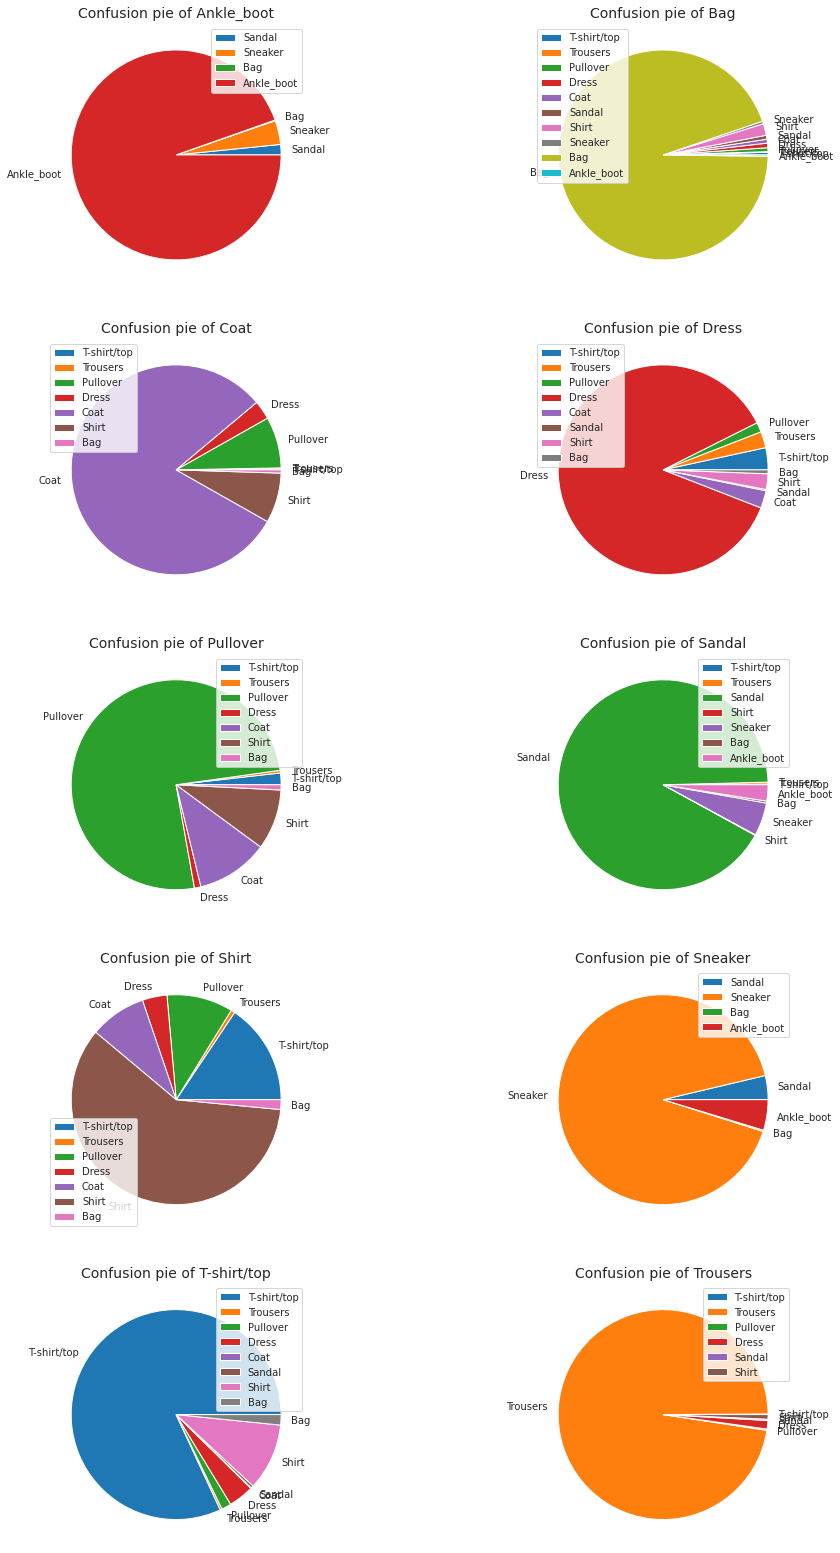

In [100]:
fig=plt.figure(figsize=(16, 28))
columns = 2
rows = 5

i=1
for j, g in conf_matrix.groupby('category_act'):
    fig.add_subplot(rows, columns, i)
    labels = g['category_pred']
    plt.pie(x=g['perc'],labels=labels)
    plt.title("Confusion pie of "+j, fontsize=14)
    plt.legend()
    i += 1

<AxesSubplot:xlabel='category', ylabel='category'>

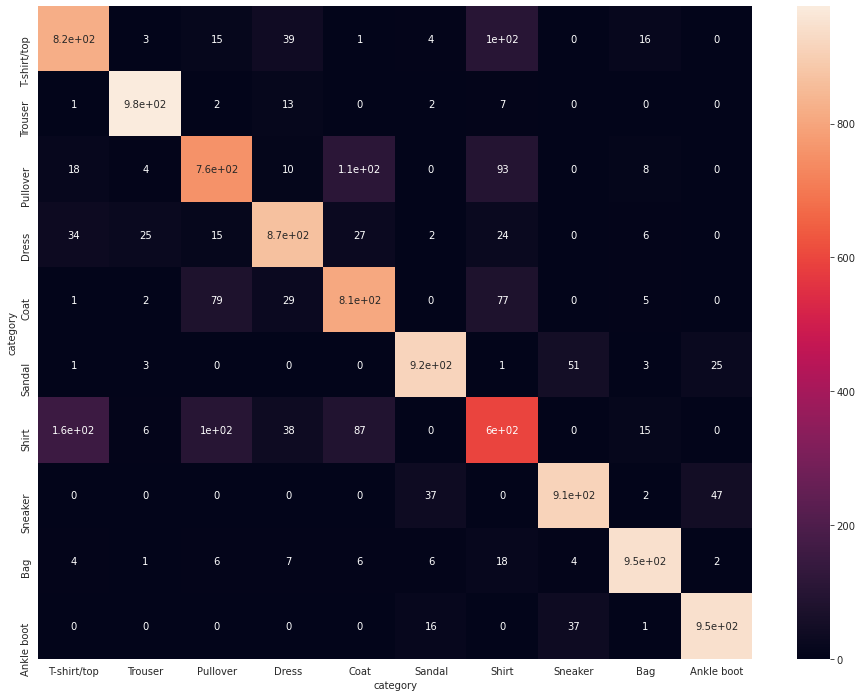

In [132]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(figsize=(16,12))
clean_conf_mat = pd.DataFrame(confusion_matrix(Y_test, test_predictions), index=category_df["category"], columns=category_df["category"])
sns.heatmap(clean_conf_mat, annot=True, ax = ax)

The following cell is taking only the maximum values, to have an idea about the accuracy of the model for each cloth category.

In [101]:
max_lr = conf_matrix.groupby(['actual'])['perc'].max().reset_index().rename(columns={"perc": "log_regr"})
max_lr

,actual,log_regr
0,0,0.819
1,1,0.975
2,2,0.756
3,3,0.867
4,4,0.807
5,5,0.916
6,6,0.596
7,7,0.914
8,8,0.946
9,9,0.946


Observations:

* Ankle boots are mainly confused with sneakers, which is ok because they are both shoes, but still different. So the gravity of this error is medium
* Coat is confused with many other categories: pullover, shirt, dress. Here the difference * is huge, the gravity of this error is high
* Pullover is confused with coat and shirt. Again the gravity is high
* Sandals are confused with sneakers, since they are both shoes, the gravity is medium
* Shirts are super confused, with t-shirt is fine (low gravity), with pullover and coats it's not that good (high gravity)
* Trousers are the least confused. That sounds logical.

## Knn

Once more, we train our algorithm using our available data. 

In [134]:
from sklearn.neighbors import KNeighborsClassifier
neigh = KNeighborsClassifier()
neigh.fit(X, Y)

KNeighborsClassifier()

We can then use the KNN method to predict the types of clothes our data belongs to. 

In [135]:
predictions = neigh.predict(X_test)

In [136]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, predictions)

0.8589

We won't do any hyperparameters optimization in this notebook, as it is already a dense notebook and hyperopt takes a long time.

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:17: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 


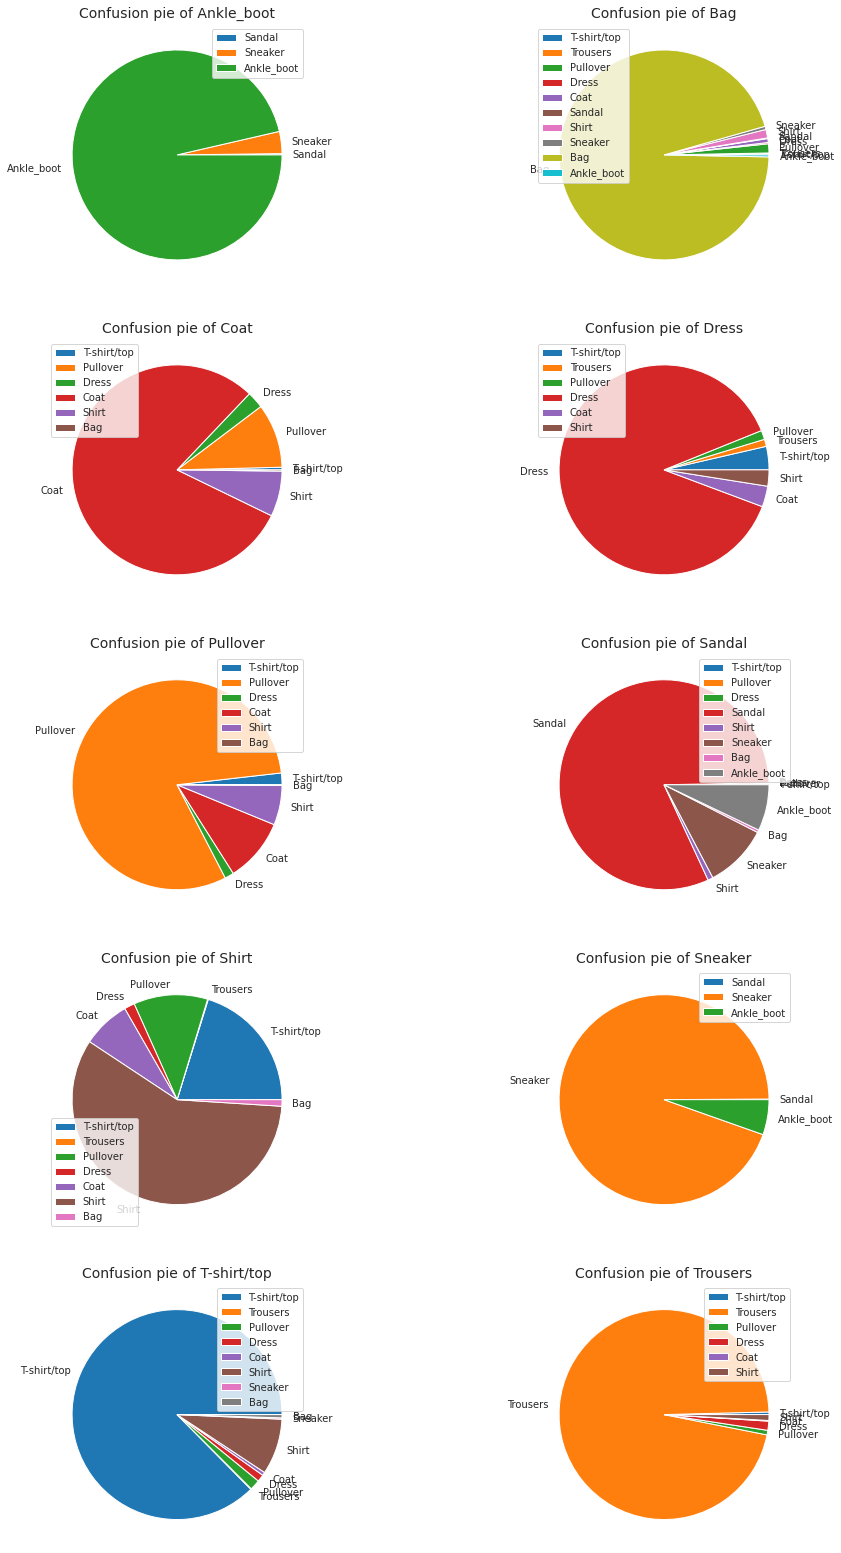

In [138]:
pd.set_option("display.max_rows", None, "display.max_columns", None) #I want to see the whole matrix although is huge
ones = np.ones(10000) #I need an array of ones to count later
test_predictions = predictions #array with all the predictions
conf = pd.DataFrame({'actual':Y_test, 'predicted':test_predictions, 'tot':ones}) #I merge the predictions with actual values
conf_matrix = conf.groupby(['actual','predicted'])['tot'].count().reset_index() #I count how many times each case happens
conf_matrix['perc'] = conf_matrix['tot']/1000
conf_matrix['category_act'] = np.where(conf_matrix['actual']== 0, 'T-shirt/top', np.where(conf_matrix['actual']== 1,'Trousers',np.where(conf_matrix['actual']== 2,'Pullover',np.where(conf_matrix['actual']== 3,'Dress',np.where(conf_matrix['actual']== 4,'Coat',np.where(conf_matrix['actual']== 5,'Sandal',np.where(conf_matrix['actual']== 6,'Shirt',np.where(conf_matrix['actual']== 7,'Sneaker',np.where(conf_matrix['actual']== 8,'Bag','Ankle_boot')))))))))
conf_matrix['category_pred'] = np.where(conf_matrix['predicted']== 0, 'T-shirt/top', np.where(conf_matrix['predicted']== 1,'Trousers',np.where(conf_matrix['predicted']== 2,'Pullover',np.where(conf_matrix['predicted']== 3,'Dress',np.where(conf_matrix['predicted']== 4,'Coat',np.where(conf_matrix['predicted']== 5,'Sandal',np.where(conf_matrix['predicted']== 6,'Shirt',np.where(conf_matrix['predicted']== 7,'Sneaker',np.where(conf_matrix['predicted']== 8,'Bag','Ankle_boot')))))))))
fig=plt.figure(figsize=(16, 28))
columns = 2
rows = 5

i=1
for j, g in conf_matrix.groupby('category_act'):
    fig.add_subplot(rows, columns, i)
    labels = g['category_pred']
    plt.pie(x=g['perc'],labels=labels)
    plt.title("Confusion pie of "+j, fontsize=14)
    plt.legend()
    i += 1

<AxesSubplot:xlabel='category', ylabel='category'>

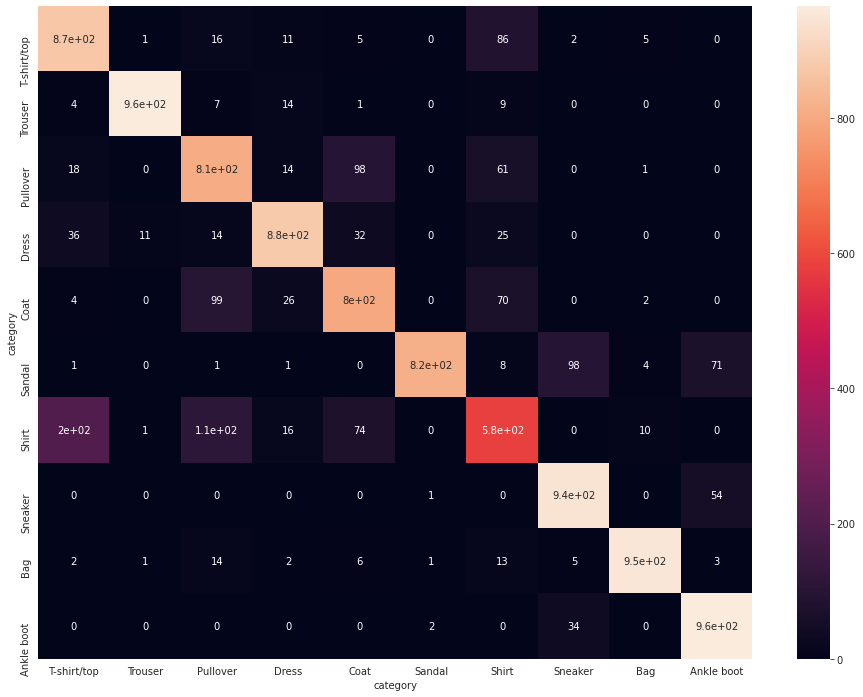

In [139]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(figsize=(16,12))
clean_conf_mat = pd.DataFrame(confusion_matrix(Y_test, test_predictions), index=category_df["category"], columns=category_df["category"])
sns.heatmap(clean_conf_mat, annot=True, ax = ax)

## Random Forest

Let us try predicting the nature of the clothes in our dataset using one more method: Random Forest! 

In [86]:
from sklearn.ensemble import RandomForestClassifier
rdf_cf = RandomForestClassifier(n_jobs=4)
rdf_cf.fit(X,Y)

RandomForestClassifier(n_jobs=4)

Once again, we train the algorithm using our train data, and then predict the nature of the clothes in our test set. 

In [140]:
predictions = rdf_cf.predict(X_test)

In [141]:
rdf_cf.score(X_test,Y_test)

0.8832

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:17: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 


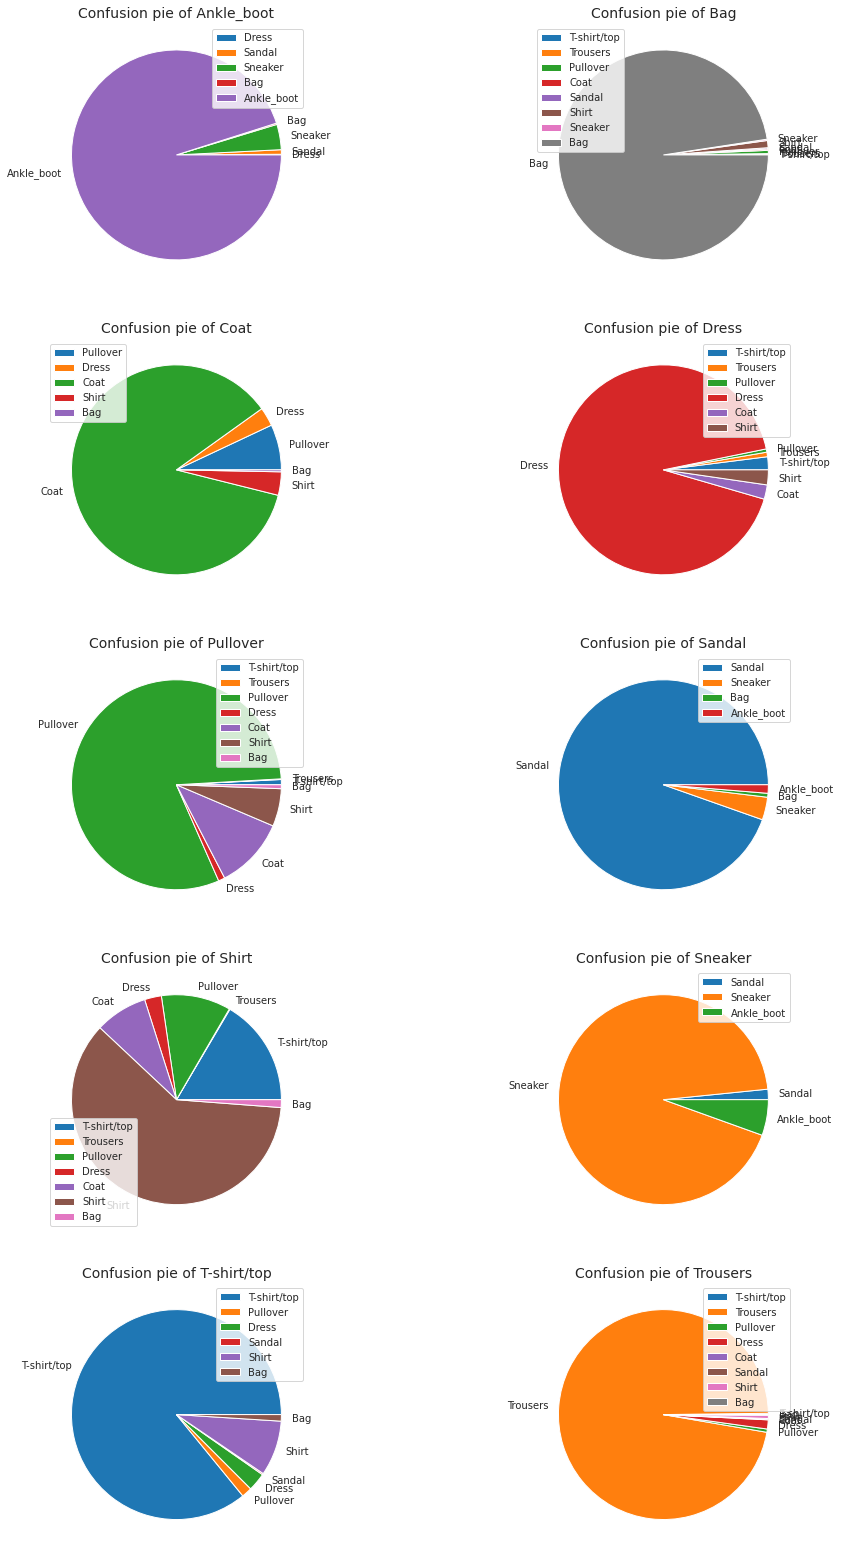

In [142]:
pd.set_option("display.max_rows", None, "display.max_columns", None) #I want to see the whole matrix although is huge
ones = np.ones(10000) #I need an array of ones to count later
test_predictions = predictions #array with all the predictions
conf = pd.DataFrame({'actual':Y_test, 'predicted':test_predictions, 'tot':ones}) #I merge the predictions with actual values
conf_matrix = conf.groupby(['actual','predicted'])['tot'].count().reset_index() #I count how many times each case happens
conf_matrix['perc'] = conf_matrix['tot']/1000
conf_matrix['category_act'] = np.where(conf_matrix['actual']== 0, 'T-shirt/top', np.where(conf_matrix['actual']== 1,'Trousers',np.where(conf_matrix['actual']== 2,'Pullover',np.where(conf_matrix['actual']== 3,'Dress',np.where(conf_matrix['actual']== 4,'Coat',np.where(conf_matrix['actual']== 5,'Sandal',np.where(conf_matrix['actual']== 6,'Shirt',np.where(conf_matrix['actual']== 7,'Sneaker',np.where(conf_matrix['actual']== 8,'Bag','Ankle_boot')))))))))
conf_matrix['category_pred'] = np.where(conf_matrix['predicted']== 0, 'T-shirt/top', np.where(conf_matrix['predicted']== 1,'Trousers',np.where(conf_matrix['predicted']== 2,'Pullover',np.where(conf_matrix['predicted']== 3,'Dress',np.where(conf_matrix['predicted']== 4,'Coat',np.where(conf_matrix['predicted']== 5,'Sandal',np.where(conf_matrix['predicted']== 6,'Shirt',np.where(conf_matrix['predicted']== 7,'Sneaker',np.where(conf_matrix['predicted']== 8,'Bag','Ankle_boot')))))))))
fig=plt.figure(figsize=(16, 28))
columns = 2
rows = 5

i=1
for j, g in conf_matrix.groupby('category_act'):
    fig.add_subplot(rows, columns, i)
    labels = g['category_pred']
    plt.pie(x=g['perc'],labels=labels)
    plt.title("Confusion pie of "+j, fontsize=14)
    plt.legend()
    i += 1

<AxesSubplot:xlabel='category', ylabel='category'>

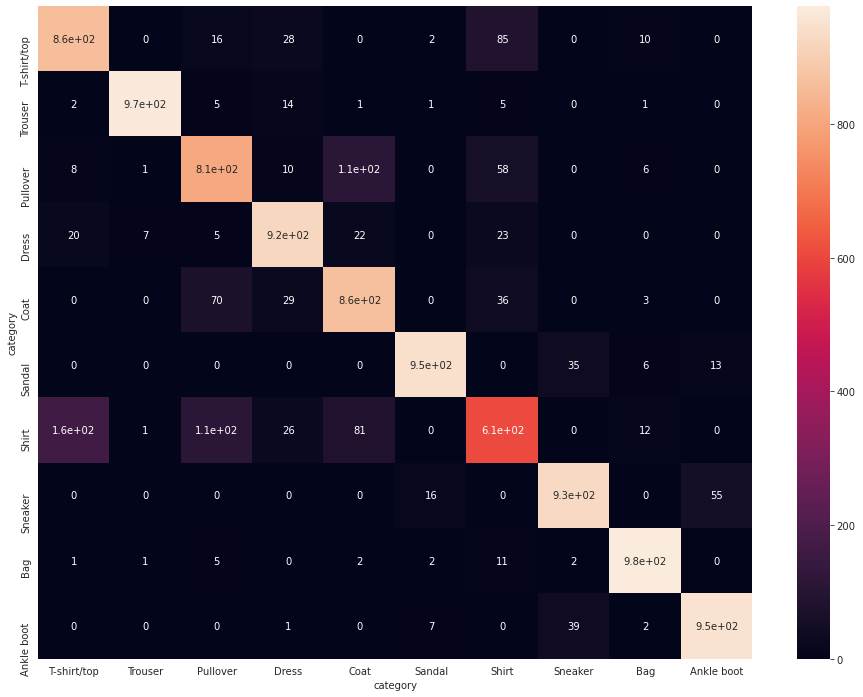

In [143]:
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(figsize=(16,12))
clean_conf_mat = pd.DataFrame(confusion_matrix(Y_test, test_predictions), index=category_df["category"], columns=category_df["category"])
sns.heatmap(clean_conf_mat, annot=True, ax = ax)

# Conclusion

## Best model

We've selected random forest as our best model, because it gives same prediction score as the others, but take way less training time than Logistic Regression and way less inference time than KNN Classifier.

## Testing our best model on almost real images

Let's see what our best model can do on images taken on the web. For simplification, we've only taken images with transparent background. But we know that this is one of the limitations of our model : if background isn't unified (for example the image of somebody wearing a shirt outside) our model would not be able to identify the shirt.

Let's see what these images look like for real.

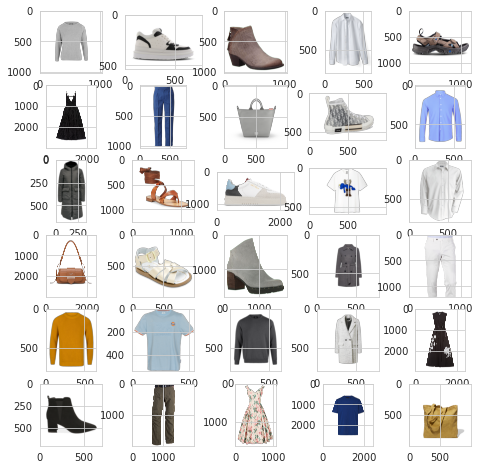

In [81]:
from imageio import imread
import glob
import math

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image_path in glob.glob("../input/real-world-fashion-mnist/*.png"):
    image = imread(image_path)
    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image)
    i += 1

plt.show()

Wow real images with colors and high resolution !

But we cannot directly fit these images to our model because :
* We have four color channel (RGB plus transparency) making the image signal a 3 dimensionnal tensor like (4, rows, columns) and our model only works for images with one color channel, so with matrix tensors
* Images are not squared, so we have to add padding around them
* Images don't have a homogeneous resolution, our model only works with images of size 28x28, so we will have to downscale them !

## Padding

We begin with some squarring through padding around the image. This kind of padding is convenient because it centers the images, exactly as in our dataset. Maybe we could have used some deep learning layers made for padding, but we didn't think of it for this step.

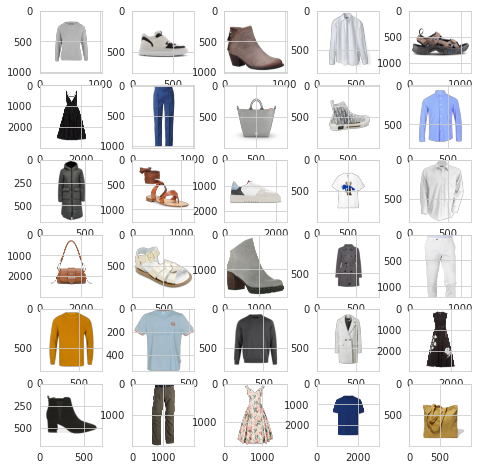

In [82]:
def preprocess_shape(image):
    if image.shape[0] == image.shape[1]:
        return image

    lines_to_add = math.floor(abs(image.shape[0] - image.shape[1])/2)
    reshaped_image = None
    if image.shape[0] > image.shape[1]:
        reshaped_image = np.zeros((image.shape[0],image.shape[0],4), dtype=np.uint8)
        reshaped_image[:image.shape[0],lines_to_add:image.shape[1]+lines_to_add] = image
    else:
        reshaped_image = np.zeros((image.shape[1],image.shape[1],4), dtype=np.uint8)
        reshaped_image[lines_to_add:image.shape[0]+lines_to_add,:image.shape[1]] = image
    
    return reshaped_image

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image_path in glob.glob("../input/real-world-fashion-mnist/*.png"):
    image = preprocess_shape(imread(image_path))
    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image)
    i += 1

plt.show()

Nice job ! Images are squarred and centered.

## Decolorization

Now we have to do something about the 4 channels. Remember, we only want one.
There are different ways to proceed, we've selected the one that makes the most sense.
For each image we've taken the mean over the 3 color channels (RGB) and masked the pixels with the transparence channel.
The masking part was necessary for some images, because althought the transparency channel was very well defining the borders of the images, other channels didn't and were active outside the cloth. We could not see it because the transparency channel did well its job. However when we averaged the 4 channels, we saw it.
So here it's nicely done, everything works fine with this way to go.

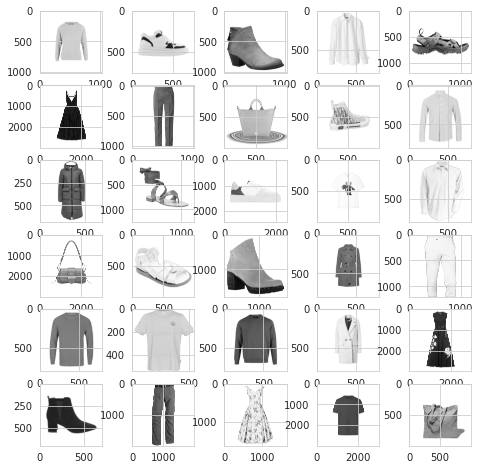

In [83]:
def preprocess_channels(image):
    return image[:,:,:3].mean(axis=-1).astype(np.uint8)*image[:,:,3]
    
fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image_path in glob.glob("../input/real-world-fashion-mnist/*.png"):
    image = preprocess_channels(preprocess_shape(imread(image_path)))
    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image, cmap="Greys")
    i += 1

plt.show()

With only one channel and with our method we still have more than enough information to distinguish categories.

In [84]:
humanized_classes = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

## Downscaling

And now the most interesting part : how do we achieve to reduce the signal of the images without losing to much information. There are several ways to go. We've selected the most simpliest, but still very interesting : it's called pooling and is very useful in deep convolutional learning to avoid overfitting in models with millions of parameters.

The idea behind this is actually complex. It's that in a matrix representing an image, pixels that are closer with regards to the manhattan distance should be processed together.
So we will average blocks of pixels or we will take the max out of these blocks. Both methods are valid.
The size of the blocks (variable kernel_size in the following code) depends here of the image processed. Each image has a different resolution in our small hand made dataset. But we know that at the end we want a 28x28 resolution. We hence just have to divide the image resolution (which we have previously squarred) by 28, in order to find the size of the square blocks.

Here we'll use some functions of the torch convolutional toolkit. To have a visual idea of what those functions are doing, please look at : https://github.com/vdumoulin/conv_arithmetic/blob/master/README.md


These torch functions work with channeled images, so we'll have to artificially transform our image matrices into 3 dimensional tensors of size (1, squarred_image_size, squarred_image_size) using torch unsqueeze function.
Plus we have to convert all our numpy matrices to torch tensors with float32 types. That's how torch works.

### Maxpooling

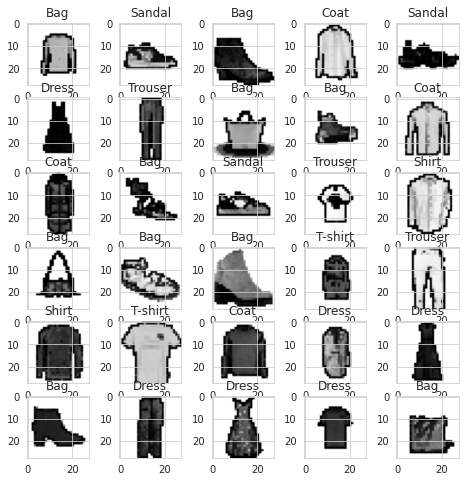

In [87]:
import torch.nn as nn
import torch

def preprocess_down_scale_with_max(image):
    target_width = target_height = 28
    kernel_size = image.shape[0] // 28
    return nn.MaxPool2d(kernel_size=kernel_size)(torch.tensor(image, dtype=torch.float32).unsqueeze(0)).squeeze(0).numpy()/255

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image_path in glob.glob("../input/real-world-fashion-mnist/*.png"):
    image = preprocess_down_scale_with_max(preprocess_channels(preprocess_shape(imread(image_path))))
    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image, cmap="Greys")
    plt.title(humanized_classes[rdf_cf.predict(image.reshape(1,28*28))[0]])
    i += 1

plt.show()

With max-pooling the images don't look like the ones of our training dataset. One interesting thing is that it underlines the borders of our objects.

### Average pooling

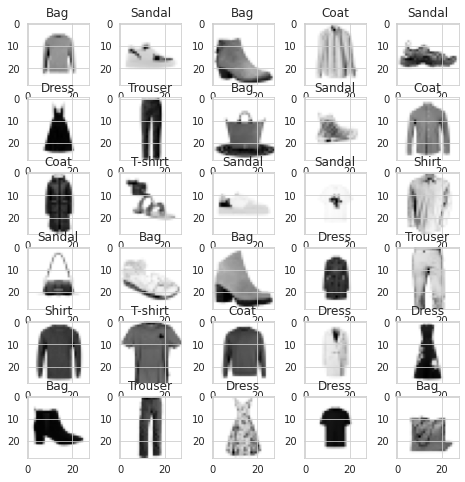

In [88]:
def preprocess_down_scale_with_avg(image):
    target_width = target_height = 28
    kernel_size = image.shape[0] // 28
    return nn.AvgPool2d(kernel_size=kernel_size)(torch.tensor(image, dtype=torch.float32).unsqueeze(0)).squeeze(0).numpy()/255

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image_path in glob.glob("../input/real-world-fashion-mnist/*.png"):
    image = preprocess_down_scale_with_avg(preprocess_channels(preprocess_shape(imread(image_path))))
    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image, cmap="Greys")
    plt.title(humanized_classes[rdf_cf.predict(image.reshape(1,28*28))[0]])
    i += 1

plt.show()

Looks more like our initial dataset ! Prediction score is far from perfect though. We've got some big errors, a few well classified object and a few small classification errors.

**All this process has taught us one new limitation of our algorithm : we loose to much information with this small resolution. Of course, here, even with low resolution we could have had a near perfect prediction score with a deep convolutional residual network, but classic algorithms would need more signal and thus a higher resolution. The only problem is the curse of the dimensionnality. And we are not sure that classic algorithm would be appropriate for higher resolution images**

## Clusturisation

There are two main reasons why we're doing K-Means here :
* Can it serves as a classification model, assuming the classes it finds are the same as ours ?
* How does K-Means behaves generally speaking ?

In [144]:
from sklearn.cluster import KMeans
kmn_cl = KMeans(n_clusters=10)
kmn_cl.fit(X)

KMeans(n_clusters=10)

In [145]:
clusters = kmn_cl.predict(X)

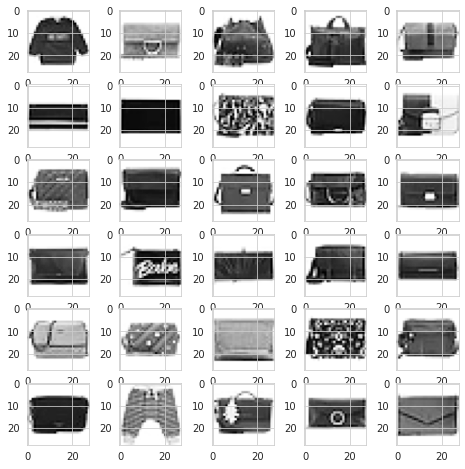

In [156]:
zero = X[clusters == 0][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

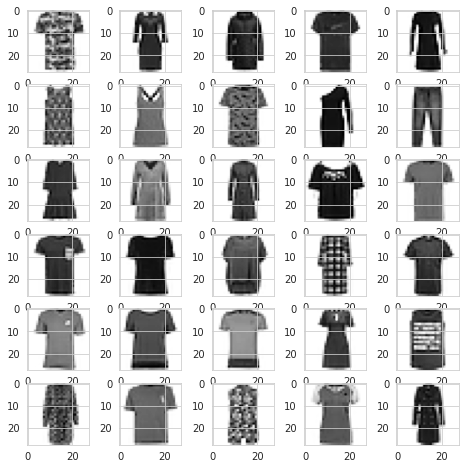

In [157]:
zero = X[clusters == 1][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

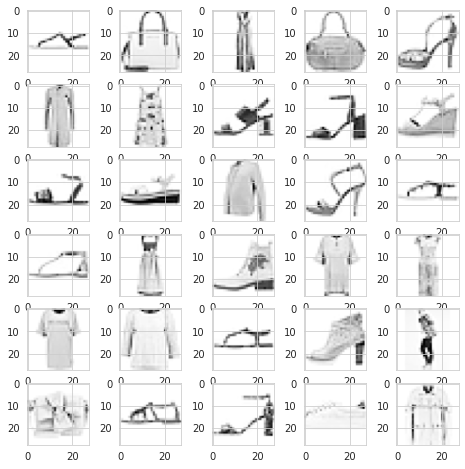

In [158]:
zero = X[clusters == 2][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

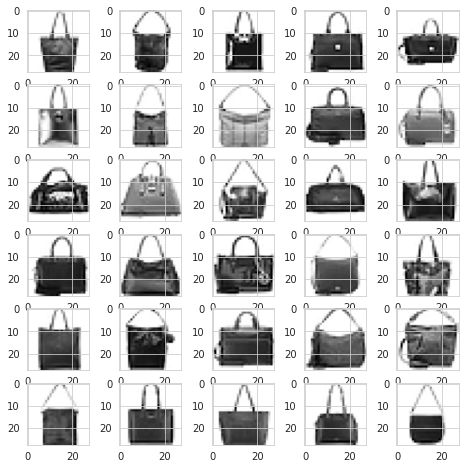

In [159]:
zero = X[clusters == 3][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

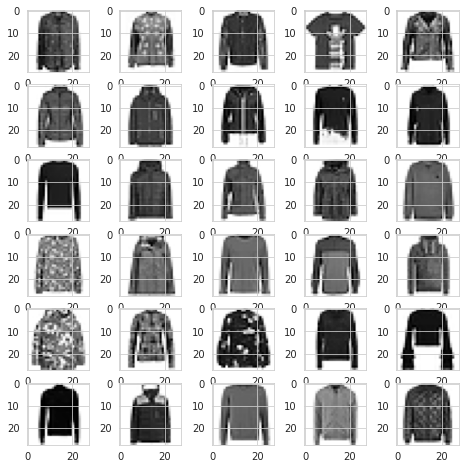

In [160]:
zero = X[clusters == 4][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

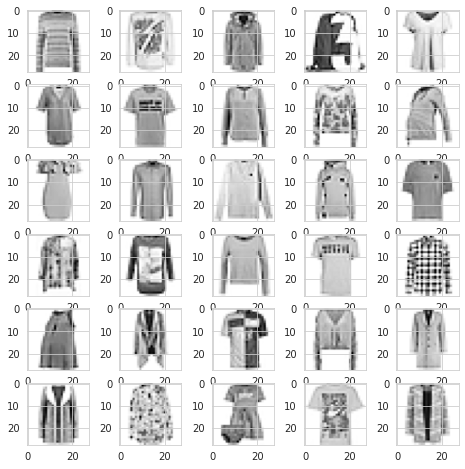

In [161]:
zero = X[clusters == 5][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

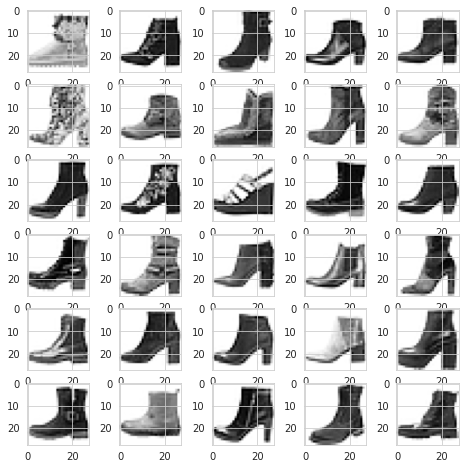

In [162]:
zero = X[clusters == 6][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

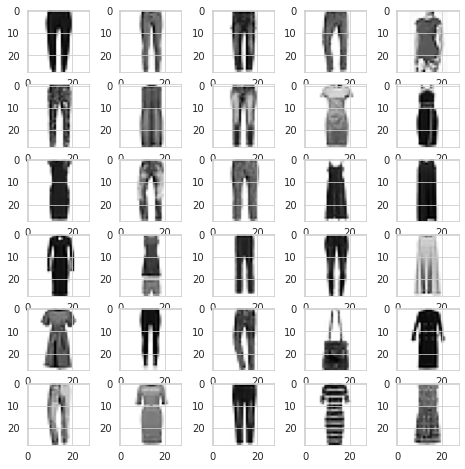

In [163]:
zero = X[clusters == 7][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

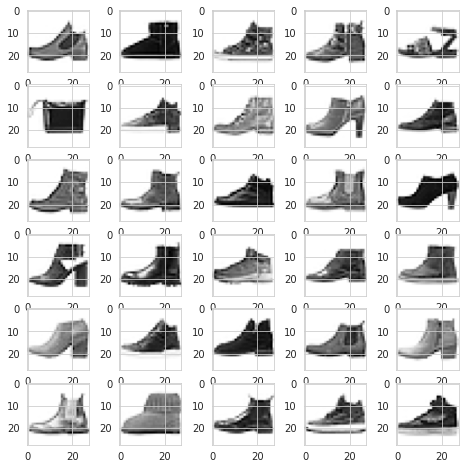

In [164]:
zero = X[clusters == 8][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

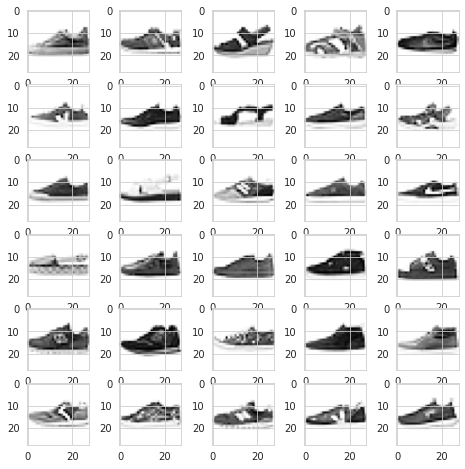

In [165]:
zero = X[clusters == 9][:30]

fig=plt.figure(figsize=(8, 8))
columns = 5
rows = 6
i = 1

for image in zero:    
    fig.add_subplot(rows, columns, i)
    plt.imshow(image.reshape((28,28)), cmap="Greys")
    i += 1

plt.show()

K-Means finds classes that make sens, because we can see strong similarities inside them. But there are not usable for our classification goal, because they don't correspond to our classes.
We can see that it classified shoes into three different classes depending on their height, two classes for bags depending on their width and height, one class for bright clothes, and 4 classes for other cloths depending on their color intensity and their width.

In [176]:
np.unique(clusters, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32),
 array([2340, 7400, 7603, 2583, 9683, 7567, 2976, 9057, 4301, 6490]))

Here we can see that some clusters are bigger than others.

## Do our clusters improve classification ?

In [168]:
X_plus_cluster = np.zeros((X.shape[0],X.shape[1]+10))
X_plus_cluster.shape

(60000, 794)

In [166]:
import torch
one_hotted = torch.nn.functional.one_hot(torch.tensor(clusters, dtype=torch.int64), num_classes=10).numpy()

In [169]:
X_plus_cluster[:,:X.shape[1]] = X
X_plus_cluster[:,X.shape[1]:] = one_hotted

In [170]:
rdf_cf = RandomForestClassifier(n_jobs=4)
rdf_cf.fit(X_plus_cluster,Y)

RandomForestClassifier(n_jobs=4)

In [171]:
X_plus_cluster = np.zeros((X_test.shape[0],X_test.shape[1]+10))
X_plus_cluster[:,:X_test.shape[1]] = X_test

In [172]:
one_hotted_test = torch.nn.functional.one_hot(torch.tensor(kmn_cl.predict(X_test), dtype=torch.int64), num_classes=10).numpy()
X_plus_cluster[:,X_test.shape[1]:] = one_hotted_test

In [173]:
rdf_cf.score(X_plus_cluster,Y_test)

0.8831

Not really !